In [24]:
#Importaciones

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Trabajo Práctico: Guía 0 - Módulos 1 y 2

**Alumno:** Mauricio Kreszczuk


**Imagen :** Orangutan.

**Formato:** JPG

**Fuente:** [Instagram @Just Nature Expeditions](https://www.instagram.com/p/DEH-bQmNh_n/)

## Ejercicio 1 - Exploración básica de una imagen
Carga de la imagen, shape, tamaños, canales.

alto: 1080
ancho: 1080
canales: 3


<function matplotlib.pyplot.show(close=None, block=None)>

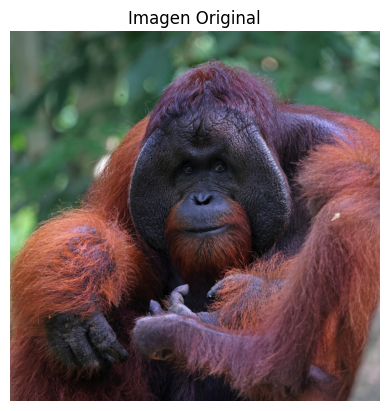

In [ ]:
### Recordar realizar la siguiente conversión BGR --> RGB antes de comenzar a manipular la imagen ###
img = cv2.imread('orangutan.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(int)
''' 
Se realiza la conversión porque librerías como OpenCV leen en BGR, pero para visualizar correctamente los colores se debe pasar al sistema RGB
'''


'''
Se tuvo que cambiar el tipo de dato debido a errores al alterar los canales.
'''


#Información de la imagen.
print('alto:', img_rgb.shape[0])
print('ancho:', img_rgb.shape[1])
print('canales:', img_rgb.shape[2])

# Imagen original
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')
plt.show

El shape tiene informacion de la estructura matricial de la imagen: cantidad de filas, cantidad de columnas y canales.

La imagen tiene un tamaño de 1080 píxeles de alto por 1080 píxeles de ancho.

Tiene 3 canales correspondientes al rojo,verde y azul (RGB).


## Ejercicio 2 - Análisis de píxeles
Evaluo un píxel específico.

rgb: [120 104 107]


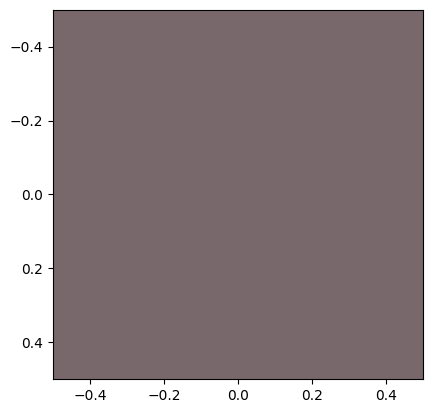

In [26]:
# Elijo el pixel (600,600) al azar
pixel = img_rgb[600,600]
print('rgb:', pixel)

pixel_ver = img_rgb[600:601,600:601]
# Es un color marron
plt.imshow(pixel_ver)
plt.show()


rgb: [120 104 107]

Los tres son bastante similares, predominando el rojo y el azul. Consiguiendo un color marron grisaceo

## Ejercicio 3 - Modificación de colores

Manipulación individual de canales (truncando).

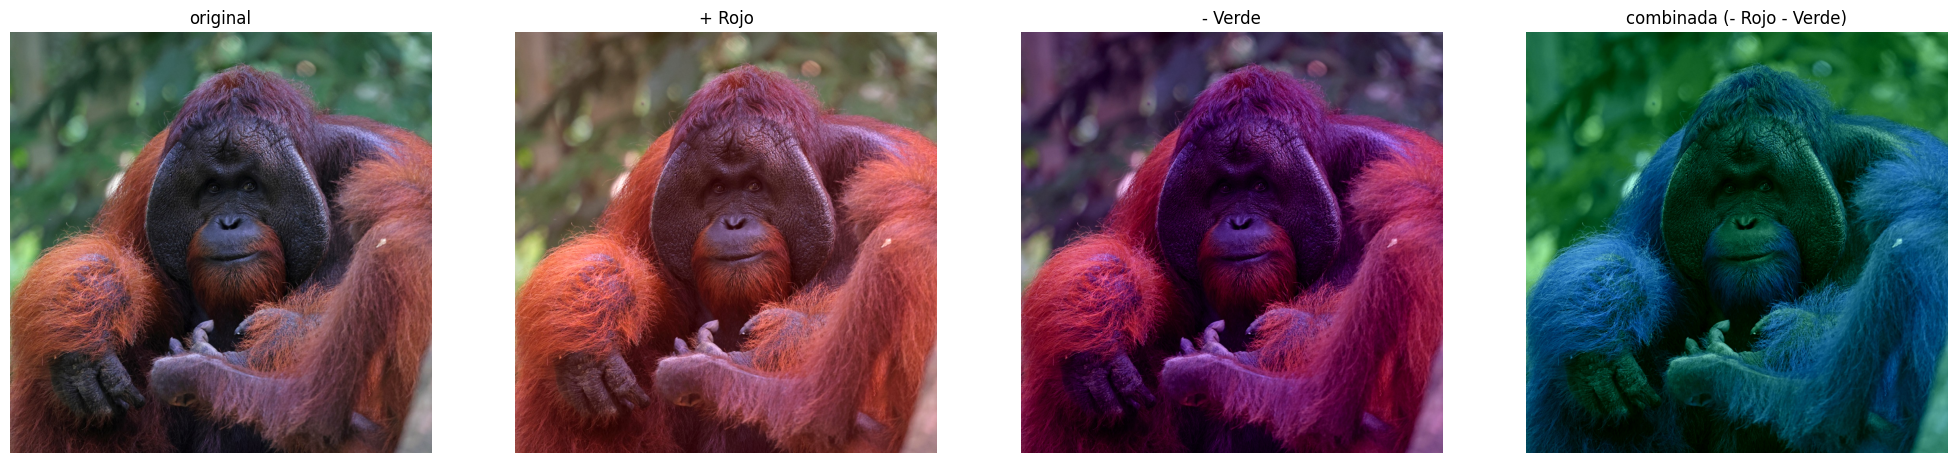

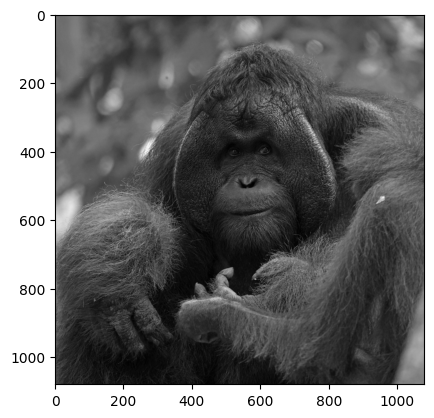

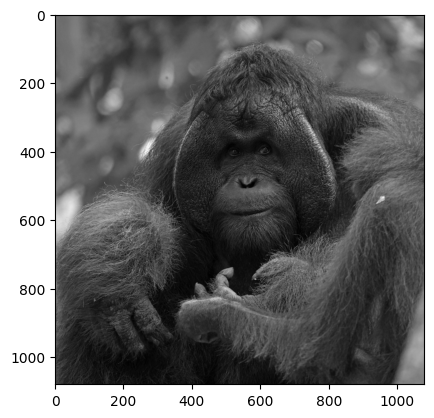

In [27]:

v1 = img_rgb.copy().astype(int)# mas rojo
v2 = img_rgb.copy().astype(int) # menos verde
v3 = img_rgb.copy().astype(int)# menos verde menos rojo

v1[:,:,0] = np.clip(v1[:,:,0] + 40, 0, 255)
#
v2[:,:,1] = np.clip(v2[:,:,1] - 50, 0, 255) #verde
#v2[:,:,1] = np.clip(v3[:,:,1].astype(int) - 50, 0, 255)

v3[:,:,2] = np.clip(v3[:,:,0] - 20, 0, 255)
v3[:,:,0] = np.clip(v3[:,:,1].astype(int) - 80, 0, 255)


plt.figure( figsize=(25,15))

plt.subplot(1,4,1)
plt.imshow(img_rgb) 
plt.title("original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(v1)
plt.title("+ Rojo")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(v2)
plt.title("- Verde")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(v3)
plt.title("combinada (- Rojo - Verde)")
plt.axis("off")

plt.show()

plt.imshow(v3[:,:,1], cmap = 'grey')
plt.show()
plt.imshow(img_rgb[:,:,1], cmap='grey')

**Observaciones visuales:**

**+ Rojo:** Al sumar intensidad a este canal, la imagen se vuelve más cálidos.

**- Verde:** La imagen tien tonos magentas/púrpuras.

**Combinada:** Modificar canales de forma independiente termina afectando globalmente a la imagen debido a cómo interactúa la "mezcla" de la luz.

## Ejercicio 4 - Canales de color: separación y exploración

(np.float64(-0.5), np.float64(1079.5), np.float64(1079.5), np.float64(-0.5))

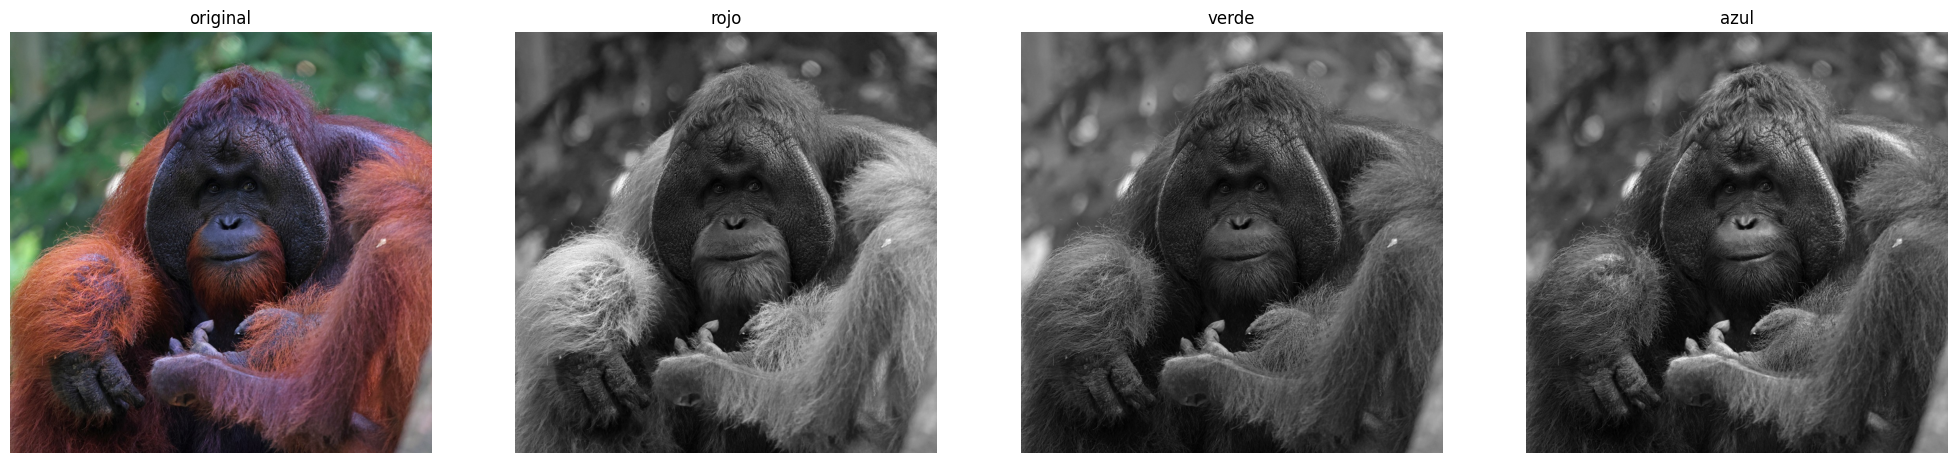

In [28]:
# Divido colores
rojo = img_rgb[:,:,0].copy()
verde = img_rgb[:,:,1].copy()
azul = img_rgb[:,:,2].copy()

cmap = 'gray'

plt.figure(figsize=(25,15))


plt.subplot(1,4,1)
plt.imshow(img_rgb,cmap)
plt.title('original')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(rojo,cmap)
plt.title('rojo')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(verde,cmap)
plt.title('verde')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(azul,cmap)
plt.title('azul')
plt.axis('off')


**Representación de los canales:**
Separo los canales y los visualizo en escala de grises. Cada uno representa la intensidad de ese color en una escala de 0 a 255. Las zonas más blancas en el "Rojo" indican una mayor concentración de ese color en la imagen original (como se ve en el pelaje). 

(np.float64(-0.5), np.float64(1079.5), np.float64(1079.5), np.float64(-0.5))

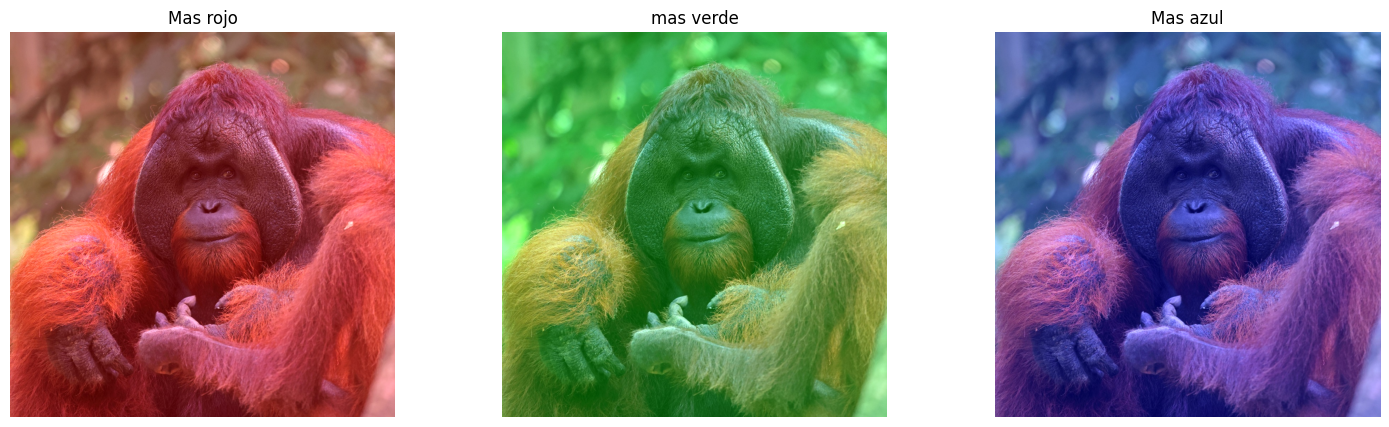

In [29]:
aumento = 80

#Rojo
v_rojo = img_rgb.copy().astype(int)
v_rojo[:,:,0] = np.clip(v_rojo[:,:,0] + aumento, 0, 255)

#Verde
v_verde = img_rgb.copy().astype(int)
v_verde[:,:,1] = np.clip(v_verde[:,:,1] + aumento, 0, 255)

# Azul
v_azul = img_rgb.copy().astype(int)
v_azul[:,:,2] = np.clip(v_azul[:,:,2] + aumento, 0, 255)

# Visualización de los resultados
plt.figure(figsize=(18, 5))

imagenes_mod = [v_rojo, v_verde, v_azul]
titulos_mod = ['Aumento de Rojo', 'Aumento de Verde', 'Aumento de Azul']

plt.subplot(1,3,1)
plt.imshow(v_rojo)
plt.title('Mas rojo')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(v_verde)
plt.title('mas verde')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(v_azul)
plt.title('Mas azul')
plt.axis('off')



Modificar un solo canal altera la orginal, por que esta es una "mezcla" de los tres colores.

## Ejercicio 5 - Reconstrucción de la imagen

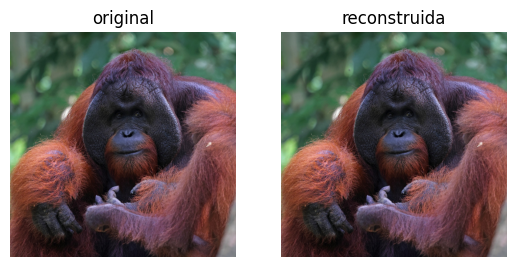

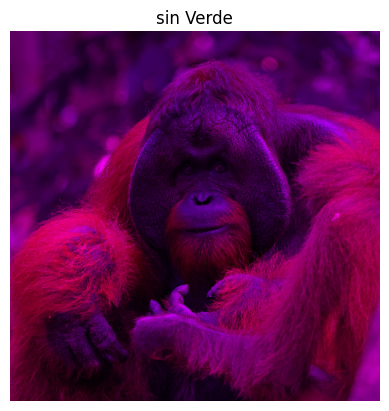

In [32]:
### Pueden usar como ayuda para reconstruir la imagen ###
reconstruida = np.stack((rojo, verde, azul), axis=2)

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstruida)
plt.title("reconstruida")
plt.axis('off')
plt.show()

# Elimino el verde
ceros = np.zeros_like(verde)
sin_verde = np.stack((rojo, ceros, azul), axis=2)

plt.imshow(sin_verde)
plt.title("sin Verde")
plt.axis('off')

plt.show()

**Conclusión de la reconstrucción:**

Al reconstruir la imagen original a partir de sus canales separados, obtenemos exactamente la misma imagen inicial. Osea que los datos RGB contienen la informacion necesaria para reproducir la imagen.

Por otro lado, eliminar por completo un canal cambia completamente la imagen, resultando en colores no naturales.

## Ejercicio 6 - Zoom y estructura de la imagen

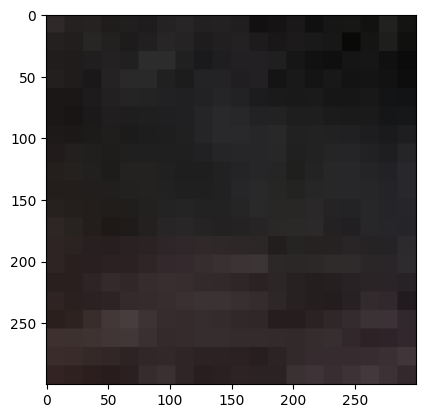

In [ ]:
###  pueden utilizar estas dos líneas para hacer zoom a la región seleccionada ###
# region = img_rgb[50:70, 50:70]
# zoom = cv2.resize(region, (300,300), interpolation=cv2.INTER_NEAREST)

region = img_rgb[580:600, 500:520]
zoom = cv2.resize(region, (300,300), interpolation=cv2.INTER_NEAREST)

plt.imshow(zoom)

plt.show()



**Zoom:**

Al hacer zoom se nota una estructura de "bloques" que forma a la imagen. Cada uno de los "bloques" visibles de representa un "píxel" (la unidad mínima de información).